In [1]:
import sys
sys.path.append('..')
import torch
from utils import *
import matplotlib.pyplot as plt
device = "cuda"
datahandler = DataHandler(
    interaction_data="games",
    semantic_data="qwen",
    device=device
)

In [2]:
def draw_bar_chart(ax: plt.Axes, values: torch.Tensor, boundaries: list[float]):
    boundaries.sort(reverse=True)
    if len(set(boundaries)) != len(boundaries):
        raise ValueError("boundaries有相同的值")
    if boundaries[-1] != 0:
        boundaries.append(0)
    for index in range(len(boundaries)):
        lower = boundaries[index]
        upper = boundaries[index-1] if index - 1 >= 0 else float('inf')
        count = ((values >= lower) & (values < upper)).sum().item()
        bar = ax.bar(str(lower), count, color='skyblue')
        # 添加数值标签
        height = bar[0].get_height()
        ax.text(bar[0].get_x() + bar[0].get_width() / 2, height + 1,
                f'{count}', ha='center', va='bottom', fontsize=10)
    ax.set_xticks(range(len(boundaries)), [str(b) for b in boundaries], rotation=45, ha='right')


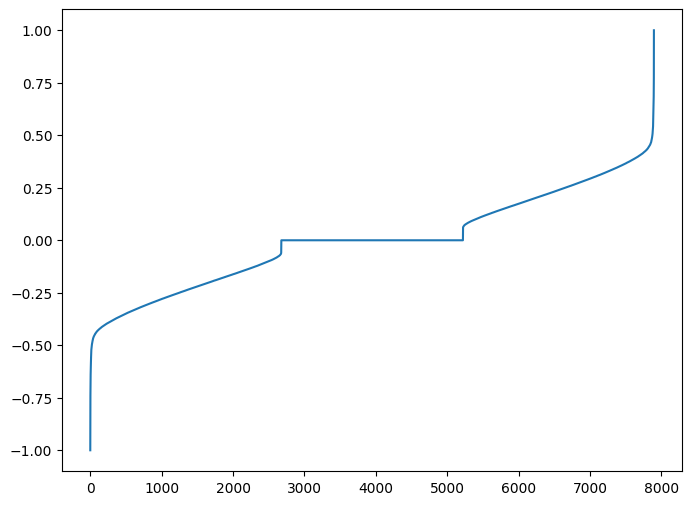

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
full_rate_matrix = torch.cat([
    torch.cat([
        torch.zeros(datahandler.num_users, datahandler.num_users, device=datahandler.device),
        datahandler.rate_matrix
    ], dim=1),
    torch.cat([
        datahandler.rate_matrix.T,
        torch.zeros(datahandler.num_items, datahandler.num_items, device=datahandler.device)
    ], dim=1)
], dim=0)

# 计算归一化拉普拉斯矩阵
degree_matrix = torch.diag(full_rate_matrix.sum(dim=1))
laplacian_matrix = degree_matrix - full_rate_matrix
# 归一化拉普拉斯矩阵
D_inv_sqrt = torch.diag(1.0 / (degree_matrix.diag() + 1e-8).sqrt())
normalized_laplacian = D_inv_sqrt @ laplacian_matrix @ D_inv_sqrt
normalized_full_rate_matrix = D_inv_sqrt @ full_rate_matrix @ D_inv_sqrt
(L, V) = torch.linalg.eigh(normalized_full_rate_matrix)
ax.plot(L.cpu().numpy())

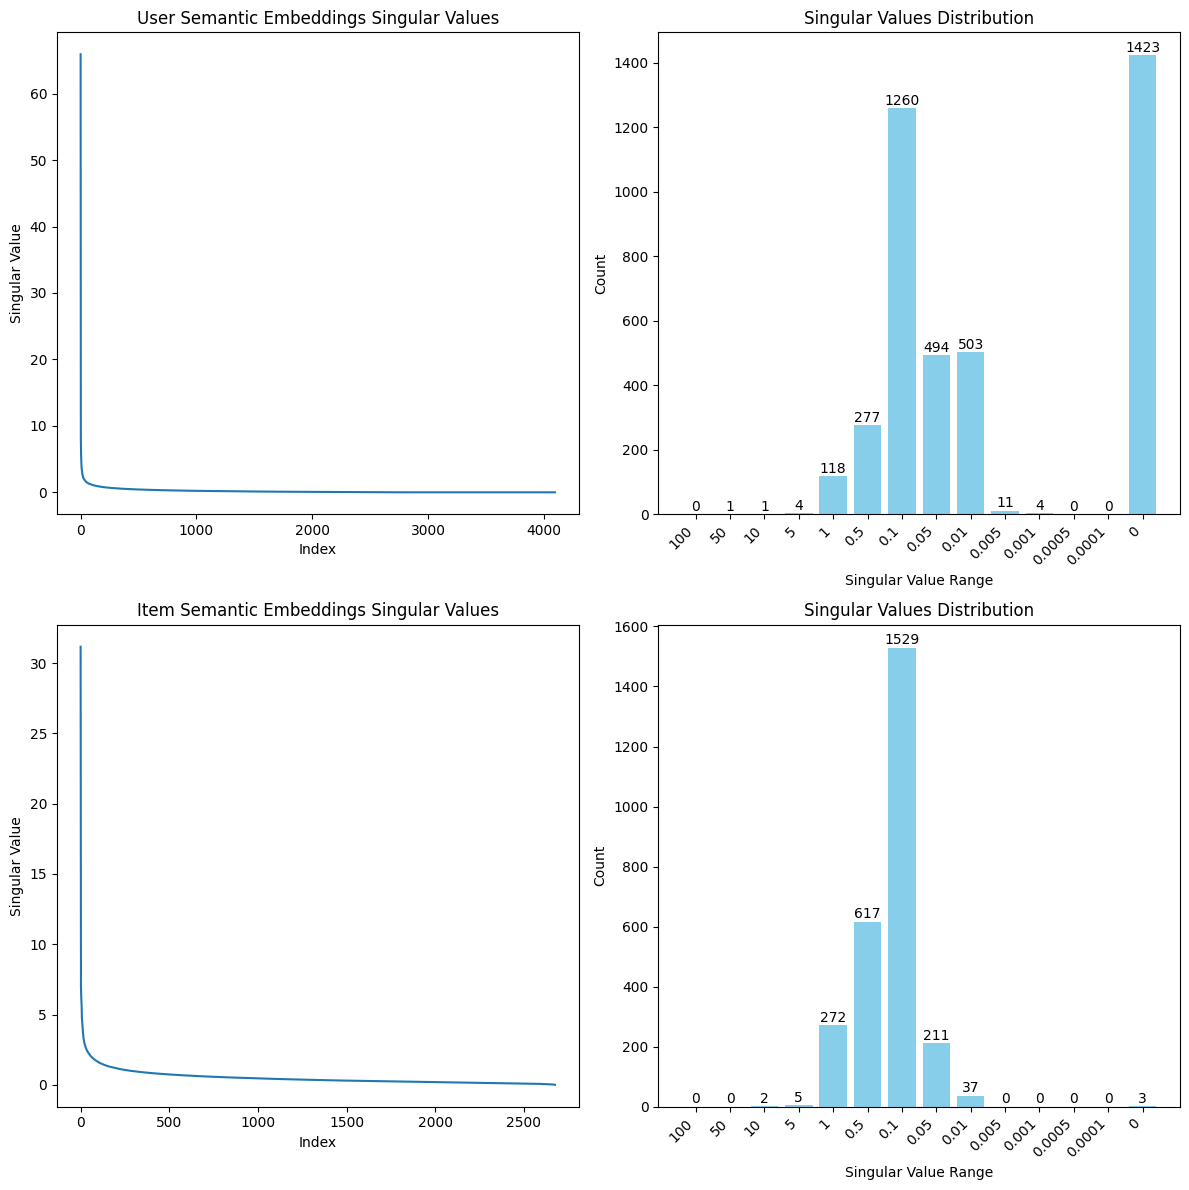

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
(U_user, S_user, V_user_T) = torch.linalg.svd(datahandler.user_semantic_embeddings, full_matrices=False)
(U_item, S_item, V_item_T) = torch.linalg.svd(datahandler.item_semantic_embeddings, full_matrices=False)
axes[0,0].plot(S_user.cpu().numpy())
axes[0,0].set_title('User Semantic Embeddings Singular Values')
axes[0,0].set_xlabel('Index')
axes[0,0].set_ylabel('Singular Value')

axes[1,0].plot(S_item.cpu().numpy())
axes[1,0].set_title('Item Semantic Embeddings Singular Values')
axes[1,0].set_xlabel('Index')
axes[1,0].set_ylabel('Singular Value')

boudary_list = [100, 50, 10, 5, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
draw_bar_chart(axes[0,1], S_user, boudary_list)
draw_bar_chart(axes[1,1], S_item, boudary_list)
# 让x轴的刻度显示在柱子的右下方

axes[0,1].set_title('Singular Values Distribution')
axes[0,1].set_xlabel('Singular Value Range')
axes[0,1].set_ylabel('Count')

axes[1,1].set_title('Singular Values Distribution')
axes[1,1].set_xlabel('Singular Value Range')
axes[1,1].set_ylabel('Count')


plt.tight_layout()
plt.show()

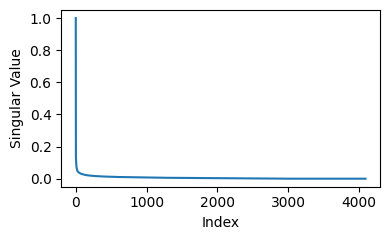

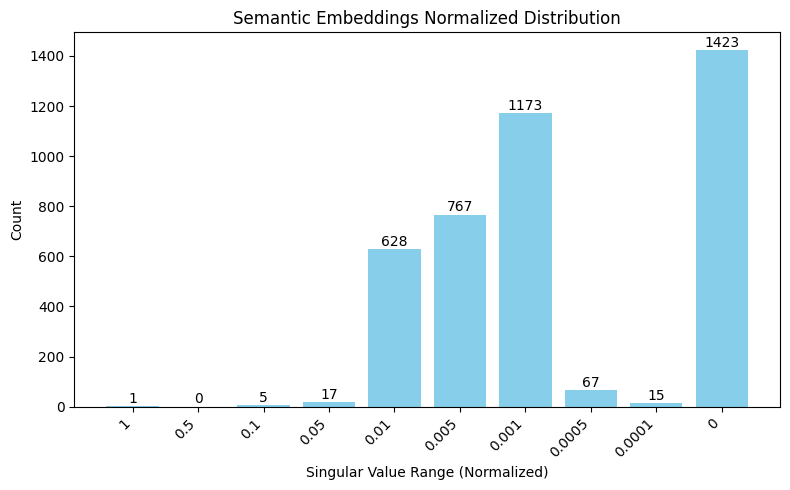

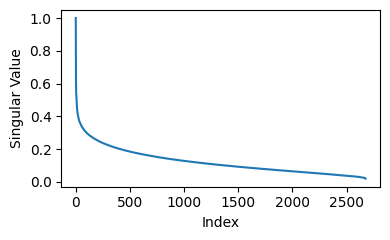

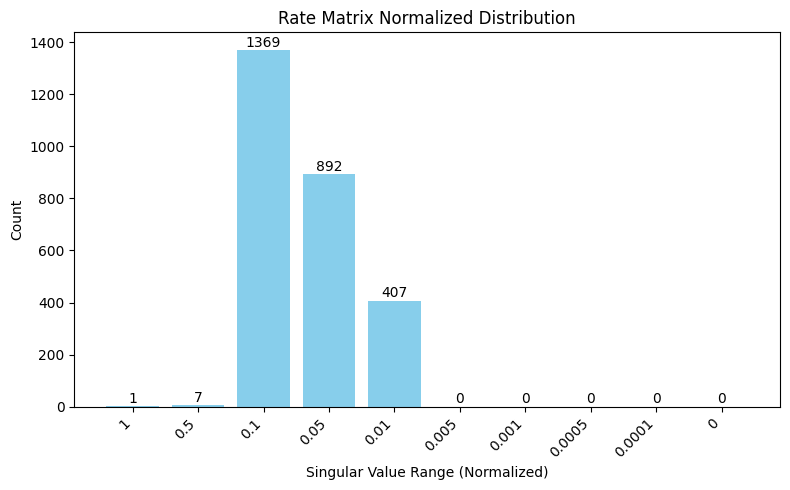

In [14]:
# 语义嵌入（user和item拼接）
concat_embeddings = torch.cat([datahandler.user_semantic_embeddings, datahandler.item_semantic_embeddings], dim=0)
(U, S_semantic, V_T) = torch.linalg.svd(concat_embeddings, full_matrices=False)
S_semantic_norm = S_semantic / S_semantic[0]

# Rate matrix
(U, S_rate, V_T) = torch.linalg.svd(datahandler.rate_matrix, full_matrices=False)
S_rate_norm = S_rate / S_rate[0]

boudary_list = [1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]

# 图1：语义嵌入奇异值曲线
fig1, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(S_semantic_norm.cpu().numpy())
ax.set_xlabel('Index')
ax.set_ylabel('Singular Value')
plt.tight_layout()
plt.show()

# 图2：语义嵌入归一化柱状图
fig2, ax = plt.subplots(figsize=(8, 5))
draw_bar_chart(ax, S_semantic_norm, boudary_list[:])
ax.set_title('Semantic Embeddings Normalized Distribution')
ax.set_xlabel('Singular Value Range (Normalized)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# 图3：Rate matrix奇异值曲线
fig3, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(S_rate_norm.cpu().numpy())
ax.set_xlabel('Index')
ax.set_ylabel('Singular Value')
plt.tight_layout()
plt.show()

# 图4：Rate matrix归一化柱状图
fig4, ax = plt.subplots(figsize=(8, 5))
draw_bar_chart(ax, S_rate_norm, boudary_list[:])
ax.set_title('Rate Matrix Normalized Distribution')
ax.set_xlabel('Singular Value Range (Normalized)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()